# Antigenic Variation Analysis - Part 1

# Import Statements (libraries + Functions)

In [1]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [2]:
#import sklearn

In [3]:
import scipy.stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import spearmanr


In [4]:
from scipy.stats import ranksums

In [5]:
from Bio import SeqIO

In [6]:
import io

In [7]:
import json

In [8]:
# import screed
# import mmh3

In [9]:
#import subprocess

In [10]:
#from pycirclize import Circos

In [11]:
# from matplotlib.patches import Patch
# import matplotlib.patches as mpatches
# from matplotlib.lines import Line2D
# from matplotlib.patches import FancyArrowPatch
# import matplotlib.ticker as mticker


In [12]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [13]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [14]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

#### Define sets of coord cols for using BioFrame

In [15]:
Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
HmReg_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols
Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")


#### Pandas Viewing Settings

In [16]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Parse `Mtb151CI` Isolate Metadata

In [17]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [18]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [19]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


# Import/parse processed H37rv genome annotations

In [20]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [21]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Parse the WHO AR Variant Catalog (Mtb)

In [22]:
WHO_ResVar_DF = pd.read_csv("../../References/WHO_MtbAMR_Catalog/WHO_resistance_variants_all.csv", sep =",")
WHO_ResVar_LVL1_DF = WHO_ResVar_DF[ WHO_ResVar_DF["confidence"] == '1) Assoc w R']
WHO_ResVar_DF.shape

(17419, 5)

In [23]:
WHO_ResVar_LVL1_DF.shape

(201, 5)

In [24]:
WHO_ConfResGenes = list(WHO_ResVar_LVL1_DF["gene"].unique())
print(len(WHO_ConfResGenes))
print( WHO_ConfResGenes )

15
['inhA', 'rrs', 'eis', 'tlyA', 'embB', 'embA', 'ethA', 'katG', 'gyrA', 'rplC', 'gyrB', 'pncA', 'rpoB', 'rpsL', 'gid']


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [25]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [26]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [27]:
Rv_HHR_DF = HmMapRegs_ParaRegs_k19w19_DF
Rv_HHR_DF.shape

(200, 15)

In [28]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [29]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

In [30]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2


#### Peak at head of each HmMap Regions DFs

In [31]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [32]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [33]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [34]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [35]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

In [36]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 38)


In [37]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 38)


In [38]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 38)


### Parse in HomologyMap Alignment Variants DFs

In [39]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [40]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(52699, 6)

In [41]:
Mtb_HM_Var_DF.shape

(79508, 14)

In [42]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 14)

# Parse curated TB antigens + epitopes (T-cell, CD4+)
Source Datasets: (Panda-24, Lindestam-16)

In [43]:
Repo_Epitope_MainDir = "../../Data/220813_MtbEpitopes"

#LPM_AllAssayedPeptides_Mapped_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.AllAssayed.V1.tsv" 

LPM_AllAssayedPeptides_WiMutInfo_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv" 

Rv_Genes_Epitope_SummStats_TSV = f"{Repo_Epitope_MainDir}/240820.RvGene.EpitopeMappingStats.V1.tsv"


In [44]:
!du -sh $Rv_Genes_Epitope_SummStats_TSV $LPM_AllAssayedPeptides_WiMutInfo_TSV

615K	../../Data/220813_MtbEpitopes/240820.RvGene.EpitopeMappingStats.V1.tsv
3.7M	../../Data/220813_MtbEpitopes/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv


### Parse in DF of all epitope mapping results (all assayed peptides, N = `18741`)

In [45]:
LPM_AllPep_V2_DF = pd.read_csv(LPM_AllAssayedPeptides_WiMutInfo_TSV, sep = "\t")
LPM_AllPep_V2_DF.shape

(18741, 30)

### Subset DF for only POSITIVE EPITOPES or NEGATIVE PEPTIDES 

In [46]:
LPM_AllPep_V2_DF.shape

(18741, 30)

In [47]:
LPM_PosEpi_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == True")
LPM_PosEpi_V2_DF.shape

(424, 30)

In [48]:
LPM_PosEpi_InL2Antigen_V2_DF = LPM_PosEpi_V2_DF.query("Antigen_LVL2 == True")
LPM_PosEpi_InL2Antigen_V2_DF.shape

(342, 30)

In [49]:
LPM_NegPep_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == False")
LPM_NegPep_V2_DF.shape

(18317, 30)

## Parse gene-level epitope mapping summary for all H37Rv genes

In [50]:
Rv_Genes_EpitopeSummary_DF = pd.read_csv(Rv_Genes_Epitope_SummStats_TSV, sep="\t")
Rv_Genes_EpitopeSummary_DF.shape

(3841, 20)

In [51]:
Rv_Genes_EpitopeSummary_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq
4,NC_000962.3,5239,7267,+,CDS,Rv0005,gyrB,information pathways,information pathways,0,8,8,0.0,6253.0,2028,False,False,0,False,NonReactive-Unq


# Parse gene-level epitope + mutation + GCE stats - (antigen/epitope info, GCE info, Mutational Burden, etc)

In [52]:
Repo_AntigenMut_MainDir = "../../Data/250609.AntigenMutationalBurdenAnalysis"

Rv_Gene_MutStats_V1_TSV = f"{Repo_AntigenMut_MainDir}/250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

PerRvPosition_EpitopeCovStats_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz"

PerRvCodon_MutationFreq_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz"

### a) Parse gene-level - mutational burden and epitope mapping summary DFs

In [53]:
Genes_GCandMutFreqStats_DF = pd.read_csv(Rv_Gene_MutStats_V1_TSV,
                                           sep = "\t")

Genes_GCandMutFreqStats_DF.shape

(3841, 36)

In [54]:
Antigen_GCandMutFreqStats_DF = Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True")
Antigen_GCandMutFreqStats_DF.shape

(53, 36)

#### Save Mutation, Epitope, and GCE stats for ALL Rv Proteins + Antigens as there own TSVs

In [55]:
!mkdir ./B_MutBurden_Results/

mkdir: cannot create directory ‘./B_MutBurden_Results/’: File exists


In [56]:
Antigen_GCandMutFreqStats_DF.to_csv("B_MutBurden_Results/MutBurden.GCE.Epitope.Stats.AntigensOnly.tsv", sep = "\t", index=False)

In [57]:
Genes_GCandMutFreqStats_DF.to_csv("B_MutBurden_Results/MutBurden.GCE.Epitope.Stats.AllRvGenes.tsv", sep = "\t", index=False) 


In [58]:
#MutBurdenStats.AllRvGenes.tsv

### b) Parse Per Codon Position Mutation Freq (Across Gubbins ASR SNP Events) + Epitope mapping coverage DFs

In [59]:
RvPerCodon_NSMutFreq_DF = pd.read_csv(PerRvCodon_MutationFreq_TSV,
                                  sep = "\t")
RvPerCodon_NSMutFreq_DF.shape 

(12132, 4)

### c) Parse Per Genome Position  Epitope mapping coverage DF

In [60]:
Rv_EpitopeCov_NonZero_DF = pd.read_csv(PerRvPosition_EpitopeCovStats_TSV,
                                  sep = "\t")

Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [61]:
Rv_EpitopeCov_NonZero_DF.head(2)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1


# Parse `Mtb151CI` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [62]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
WGA151_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
WGA151_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

WGA151_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{WGA151_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
WGA151_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSandEpitope.All.V2.tsv"  


RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV = f"{Gubbins_V1_OutputDir}/Gubbins.All_GCEs.AnnoBy.EpitopeEffect.V3.tsv"

WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"] = RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV



######### Add Event to Paralog Mapping Results File Paths ##########

EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

WGA151_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
WGA151_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

####################################################################


## Parse Gene Conv Event Info (pGCEs + mGCEs)

In [63]:
pGCE_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"],
                         sep = "\t")

pGCE_DF.shape

(324, 51)

In [64]:
pGCE_EventIDs = pGCE_DF["EventID"].unique()
len(pGCE_EventIDs)

324

#### Filter All putative GC events to MAPPED GC events

In [65]:
mGCE_DF = pGCE_DF.query("(Max_KmerMatch_ToHm > 0.5)")
mGCE_DF.shape

(213, 51)

In [66]:
mGCE_EventIDs = mGCE_DF["EventID"].unique()
len(mGCE_EventIDs)

213

In [67]:
pGCE_DF.head(1)

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,104038.5,879,NaN,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,2,1,0,0,PR_HmRegion_002,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,True,False,0,0,0,.


## Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [68]:
Gub_SNPs_V2_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"],
                                         sep = "\t")

Gub_SNPs_V2_DF.shape

(26508, 24)

In [69]:
Gub_SNPs_V2_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,MissenseMut,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,True,lineage5,0
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,False,lineage5,0
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,False,lineage5,0
3,16515,Node_1,N1176,T,C,NaN,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,True,lineage5,0
4,34063,Node_1,N1176,C,T,NaN,34062,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34062,34063,False,lineage5,0


### Subset Gubbins ASR SNPs (V2 Table) into groups of interest

In [70]:
Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF[~Gub_SNPs_V2_DF["Mut_AA"].isna()].query("Ref_AA != Mut_AA")

Gub_SNPs_NSMutIn_pGCE_DF    = Gub_SNPs_NSMutOnly_DF.query("EventID != 'None'")

Gub_SNPs_NSMutIn_mGCE_DF    = Gub_SNPs_NSMutOnly_DF[ Gub_SNPs_NSMutOnly_DF["EventID"].isin(mGCE_EventIDs) ]

Gub_SNPs_NSMutInEpitope_DF  = Gub_SNPs_NSMutOnly_DF.query(" N_Epitopes_Overlap > 0 ")


# Begin Analysis

# Part 1: Overview of epitope mapping dataset (T Cell Antigens + Epitopes)


## 1.A) Look at  curated stats of epitope mapping dataset

#### a) `18,371` unique peptide sequences assayed across `3841` unique proteins

#### b) `307` positive epitopes (MHC-II) detected across 134 unique proteins (Putative Antigens)

#### c) `53` high-confidence antigens identified from this data (`>= 2 epitopes validated in the same protein`)

#### d) `226` unique epitope sequences are find across the `53` high-confidence antigens.

#### Look at shape of DFs with epitope mapping results

In [71]:
print("LPM_AllPep_V2_DF:", LPM_AllPep_V2_DF.shape)
print("LPM_PosEpi_V2_DF:", LPM_PosEpi_V2_DF.shape)
print("LPM_PosEpi_InL2Antigen_V2_DF:", LPM_PosEpi_InL2Antigen_V2_DF.shape)
print("LPM_NegPep_V2_DF:", LPM_NegPep_V2_DF.shape)

LPM_AllPep_V2_DF: (18741, 30)
LPM_PosEpi_V2_DF: (424, 30)
LPM_PosEpi_InL2Antigen_V2_DF: (342, 30)
LPM_NegPep_V2_DF: (18317, 30)


In [72]:
#LPM_AllPep_V2_DF.head()

### How many unique peptides and proteins assayed? (`18371` unique peptides, `3841` unique proteins)

In [73]:
LPM_AllPep_V2_DF["Epitope_Seq"].nunique()

18371

In [74]:
LPM_AllPep_V2_DF["Symbol"].nunique()

3841

### How many unique positive epitopes are detected? (`307` unique epitopes across 135 unique proteins)

In [75]:
LPM_PosEpi_V2_DF["Epitope_Seq"].nunique()

307

### How many proteins are classified as an L2 Antigen (`>= 2 epitopes validated`)? (`53` antigens classified) 

In [76]:
LPM_PosEpi_InL2Antigen_V2_DF["Symbol"].nunique()

53

### How many unique epitopes are found across all 53 L2 Antigens? (`226` unique epitope sequences)

In [77]:
LPM_PosEpi_InL2Antigen_V2_DF["Epitope_Seq"].nunique()

226

## 1.B) Summarize # of epitopes and total peptides assayed + positive epitopes across ALL ANTIGENS

In [78]:
#Rv_Genes_EpitopeSummary_DF.columns

In [79]:
Simple_EpiMap_Cols = ["H37rv_GeneID", "Symbol", "N_Pos", "N_Neg", "Total", 'Antigen_LVL2', "HasHmRegion", "AntigenLVL2_And_HHR_Comb"] 

PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF = Rv_Genes_EpitopeSummary_DF.query("Antigen_LVL2 == True")[Simple_EpiMap_Cols]

PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF = PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF.sort_values(["N_Pos"], ascending=False)

PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF.index = PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF["Symbol"]

In [80]:
PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF.shape

(53, 8)

In [81]:
PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF.head()

,H37rv_GeneID,Symbol,N_Pos,N_Neg,Total,Antigen_LVL2,HasHmRegion,AntigenLVL2_And_HHR_Comb
Symbol,,,,,,,,
PPE18,Rv1196,PPE18,27,56,83,True,True,Antigen-HHR
esxH,Rv0288,esxH,23,3,26,True,False,Antigen-Unq
esxB,Rv3874,esxB,21,2,23,True,False,Antigen-Unq
esxA,Rv3875,esxA,19,3,22,True,False,Antigen-Unq
PPE19,Rv1361c,PPE19,16,21,37,True,True,Antigen-HHR


### Save TSV of EpitopeMappingStats for the L2 Antigens (`N = 53`)

In [82]:
!mkdir ./A_EpitopeMapping_Results/

mkdir: cannot create directory ‘./A_EpitopeMapping_Results/’: File exists


In [83]:
Antigen_EpitopeMappingStats_TSV = "./A_EpitopeMapping_Results/EpitopeMappingStats.53Antigens.tsv"

PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF.to_csv(Antigen_EpitopeMappingStats_TSV, sep = "\t", index=False)


### Look at epitope mapping stats for all L2 antigens (N = 53)

In [84]:
PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF

,H37rv_GeneID,Symbol,N_Pos,N_Neg,Total,Antigen_LVL2,HasHmRegion,AntigenLVL2_And_HHR_Comb
Symbol,,,,,,,,
PPE18,Rv1196,PPE18,27,56,83,True,True,Antigen-HHR
esxH,Rv0288,esxH,23,3,26,True,False,Antigen-Unq
esxB,Rv3874,esxB,21,2,23,True,False,Antigen-Unq
esxA,Rv3875,esxA,19,3,22,True,False,Antigen-Unq
PPE19,Rv1361c,PPE19,16,21,37,True,True,Antigen-HHR
PPE42,Rv2608,PPE42,16,106,122,True,False,Antigen-Unq
fbpB,Rv1886c,fbpB,16,56,72,True,False,Antigen-Unq
fbpA,Rv3804c,fbpA,13,65,78,True,False,Antigen-Unq
esxW,Rv3620c,esxW,12,7,19,True,True,Antigen-HHR


### Look at epitope mapping stats for all IGRA+Vaccine antigens (N = 12)

In [85]:
RvIDs_IGRA_And_9Vaccine_Antigens_List_Lind16 = ['Rv3875', 'Rv3874', 'Rv0288', 
                                                'Rv3619c', 'Rv3620c',  'Rv2660c', 
                                                'Rv0125',  'Rv3804c', 
                                                'Rv1886c', 'Rv1196','Rv2608']

len(RvIDs_IGRA_And_9Vaccine_Antigens_List_Lind16)

11

In [86]:
Simple_EpiMap_TopAntigen_Cols = ["H37rv_GeneID", "Symbol", "Length", "N_Pos", "N_Neg", "Total", "HasHmRegion", "AntigenLVL2_And_HHR_Comb"] 


In [87]:
IGRAandVaccine_Antigens_EpitopeMap_PosNeg_Stats_V2_DF = Rv_Genes_EpitopeSummary_DF[Rv_Genes_EpitopeSummary_DF["H37rv_GeneID"].isin(RvIDs_IGRA_And_9Vaccine_Antigens_List_Lind16)]

In [88]:
IGRAandVaccine_Antigens_EpitopeMap_PosNeg_Stats_V2_DF[Simple_EpiMap_TopAntigen_Cols].shape

(11, 8)

In [89]:
IGRAandVaccine_Antigens_EpitopeMap_PosNeg_Stats_V2_DF[Simple_EpiMap_TopAntigen_Cols]

,H37rv_GeneID,Symbol,Length,N_Pos,N_Neg,Total,HasHmRegion,AntigenLVL2_And_HHR_Comb
123,Rv0125,pepA,1068,3,69,72,False,Antigen-Unq
286,Rv0288,esxH,291,23,3,26,False,Antigen-Unq
1172,Rv1196,PPE18,1176,27,56,83,True,Antigen-HHR
1852,Rv1886c,fbpB,978,16,56,72,False,Antigen-Unq
2551,Rv2608,PPE42,1743,16,106,122,False,Antigen-Unq
2601,Rv2660c,Rv2660c,228,2,12,14,False,Antigen-Unq
3537,Rv3619c,esxV,285,10,9,19,True,Antigen-HHR
3538,Rv3620c,esxW,297,12,7,19,True,Antigen-HHR
3720,Rv3804c,fbpA,1017,13,65,78,False,Antigen-Unq
3790,Rv3874,esxB,303,21,2,23,False,Antigen-Unq


In [90]:
IGRAandVaccine_Antigens_EpitopeMap_PosNeg_Stats_V2_DF["Length"].values / 3

array([356.,  97., 392., 326., 581.,  76.,  95.,  99., 339., 101.,  96.])

### Save TSV of EpitopeMappingStats for the IGRA and Vaccine Antigens (`N = 11`)

In [91]:
IGRAandVaccine_Antigen_EpitopeMappingStats_TSV = "./A_EpitopeMapping_Results/EpitopeMappingStats.IGRAandVaccineAntigens.tsv"

IGRAandVaccine_Antigens_EpitopeMap_PosNeg_Stats_V2_DF[Simple_EpiMap_TopAntigen_Cols].to_csv(IGRAandVaccine_Antigen_EpitopeMappingStats_TSV, sep = "\t", index=False)

### Plot distribution of Positive and Negative peptides across ALL L2-Antigens

In [92]:
!mkdir A_EpitopeMapping_Results/

mkdir: cannot create directory ‘A_EpitopeMapping_Results/’: File exists


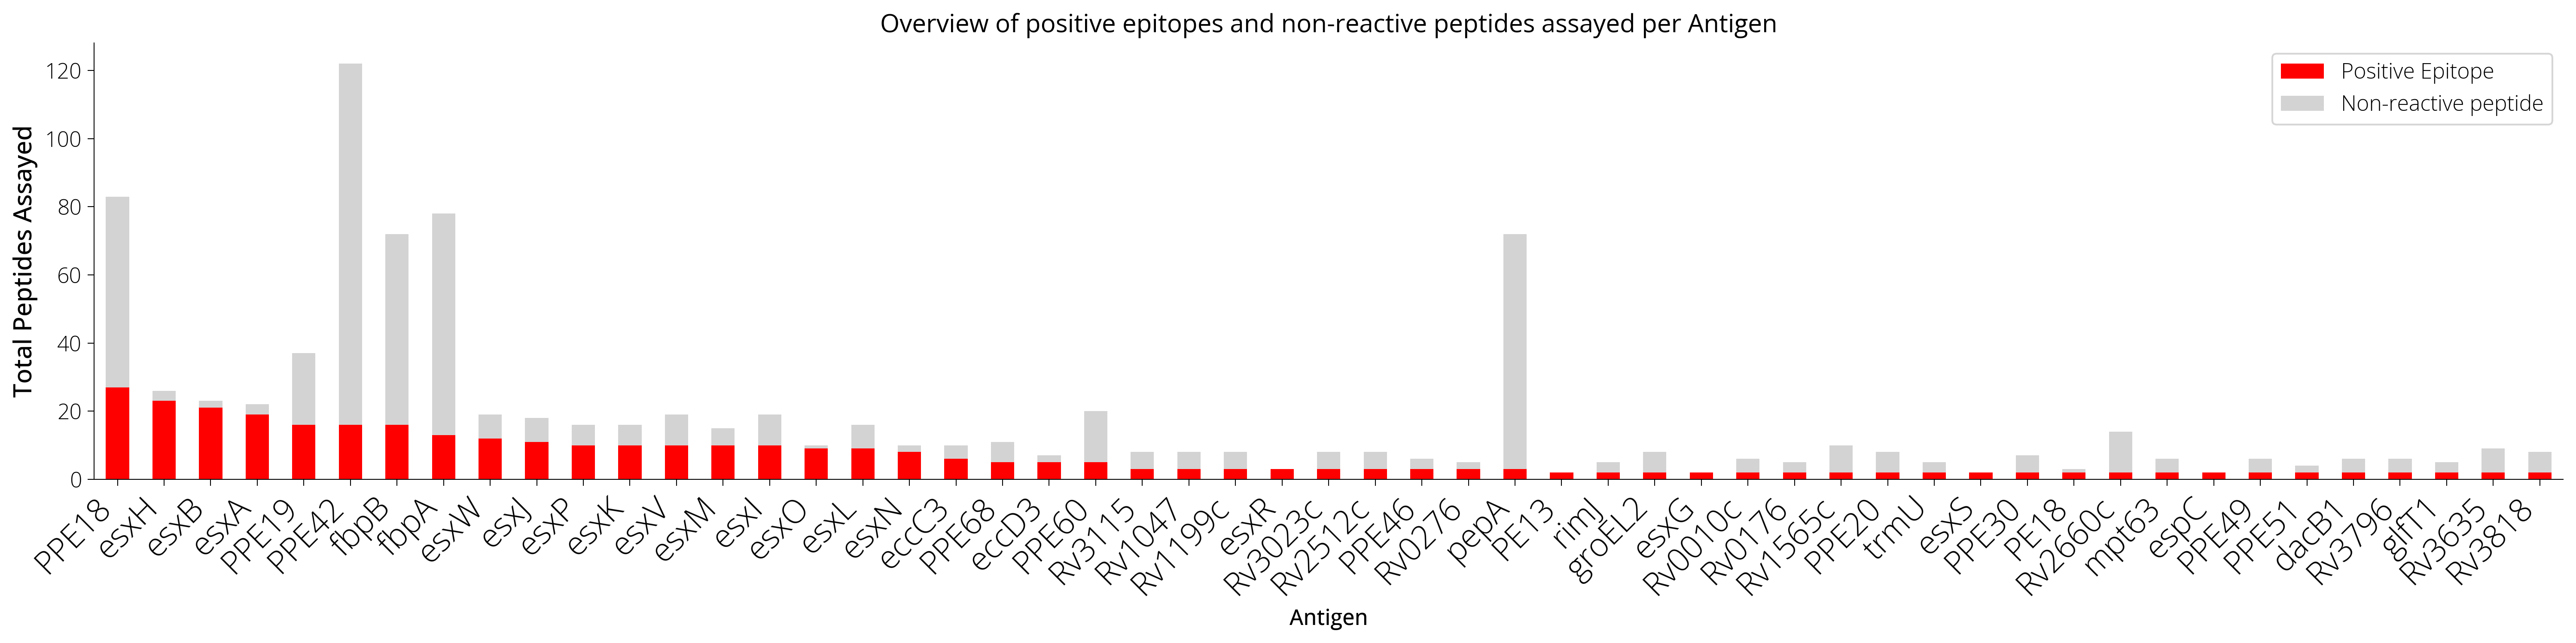

In [93]:
# Sort the DataFrame by the total number of epitopes tested per gene

# Plotting the stacked bar plot with sorted x-axis
PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF.drop(columns=['Total']).plot(kind='bar', stacked=True, figsize=(20, 5),
                                                                                        color=[ 'red', 'lightgrey'])

plt.title('Overview of positive epitopes and non-reactive peptides assayed per Antigen', fontsize= 14)

plt.xlabel('Antigen', fontsize= 12)
plt.ylabel('Total Peptides Assayed', fontsize= 14)
#plt.legend(title='Epitope Status', labels=['Negative', 'Positive'], loc= "upper right", fontsize= 12)
plt.legend( labels=['Positive Epitope', 'Non-reactive peptide'], loc= "upper right", fontsize= 12)

plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(fontsize=12)

plt.tight_layout()
sns.despine()

plt.savefig('./A_EpitopeMapping_Results/EpitopeMappingStats.53Antigens.Barplot.V1.svg')
plt.savefig('./A_EpitopeMapping_Results/EpitopeMappingStats.53Antigens.Barplot.V1.png')

# Display the plot
plt.show()

### What is the relationship between the "# of positive epitopes" and "# of peptides assayed" for each antigen?

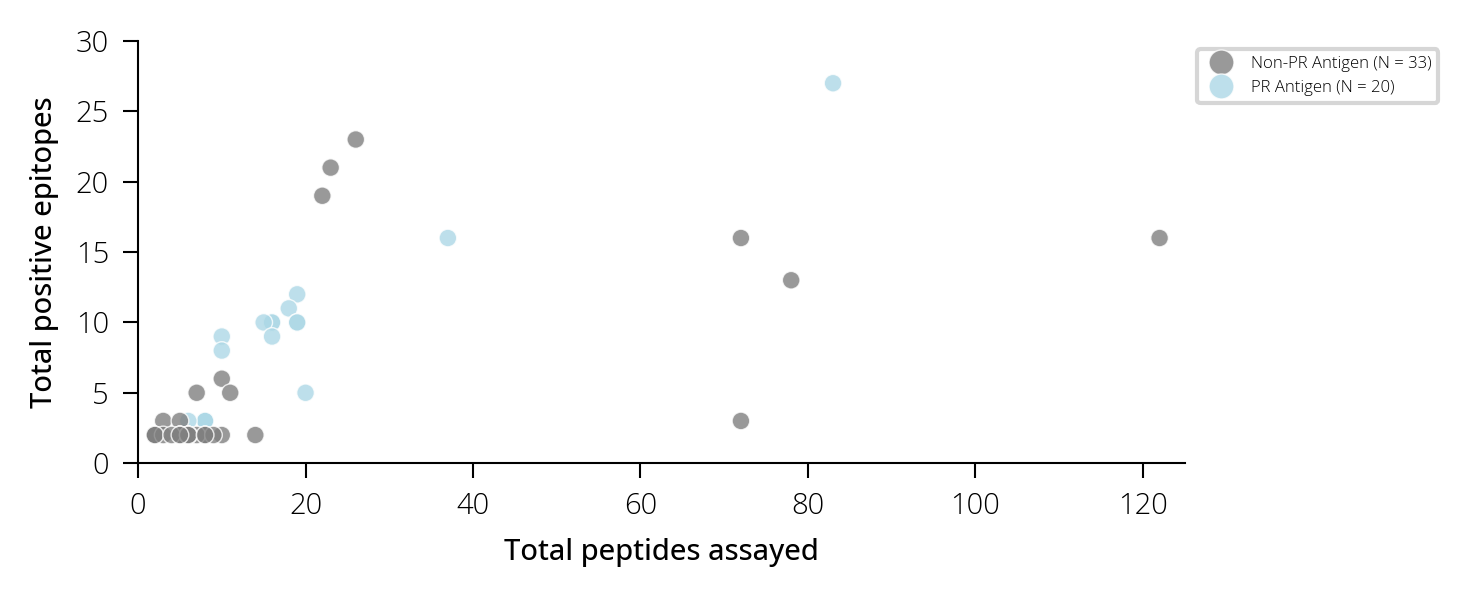

In [94]:
fig, ax = plt.subplots(figsize=(5, 2))  # Correct way to get both fig and ax
sns.scatterplot(
    x="Total", y="N_Pos", hue="HasHmRegion",
    palette={True: "lightblue", False: "grey"},
    data = PerL2Antigen_EpitopeMap_PosNeg_Stats_V2_DF,
    legend=True, alpha=0.8, size = 1,
    ax=ax
)

ax.set_xlabel("Total peptides assayed")
ax.set_ylabel("Total positive epitopes")

# Get legend handles and set custom labels
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles,
          labels=['Non-PR Antigen (N = 33)', 'PR Antigen (N = 20)'],
          loc="upper right", bbox_to_anchor=(1.25, 1), fontsize=4)

ax.set_xlim(0, 125)
ax.set_ylim(0, 30)

sns.despine()
plt.tight_layout()
plt.savefig('./A_EpitopeMapping_Results/EpitopeMappingStats.53Antigens.ScatterPlot.V1.svg')
plt.savefig('./A_EpitopeMapping_Results/EpitopeMappingStats.53Antigens.ScatterPlot.V1.png')

plt.show()


# Part 2: Analysis of GENOME-wide mutation burden of antigens

## Breakdown of all H37Rv proteins grouped by `Antigen` and `HHR` status

Categories: (`Ag-HHR`, `NonAg-HHR`, `Ag-NonHHR`, `NonAg-NonHHR`)

`Ag-HHR`: 20 genes <br>
`NonAg-HHR`: 204 genes <br>
`Ag-NonHHR`: 33 genes <br>
`NonAg-NonHHR`: 3584 genes <br>


In [95]:
Genes_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
NonReactive-Unq    3584
NonReactive-HHR     204
Antigen-Unq          33
Antigen-HHR          20
Name: count, dtype: int64

#### How many total antigens are detected? (`53 total, 20 in HHR, 33 in Non-HHR`)

In [96]:
Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True").shape

(53, 36)

## Plot normalized mutational burden between protein categories
(`Ag-HHR`, `NonAg-HHR`, `Ag-NonHHR`, `NonAg-NonHHR`)

In [97]:
!mkdir ./B_MutBurden_Results/

mkdir: cannot create directory ‘./B_MutBurden_Results/’: File exists


#### Code to create plot

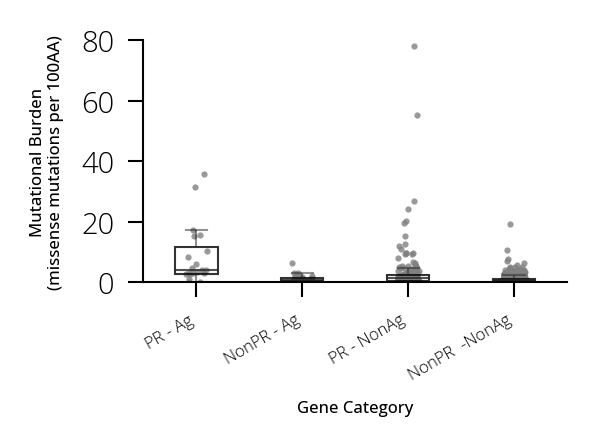

In [122]:
GWMutR_fig, GWMutR_ax = plt.subplots(figsize=(2, 1.5))

in_GeneInfo_DF = Genes_GCandMutFreqStats_DF
X_Order = ['Antigen-HHR', 'Antigen-Unq',  'NonReactive-HHR', 'NonReactive-Unq',  ]

# 2) Strip
sns.stripplot(
    x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
    order=X_Order, data=in_GeneInfo_DF, color = "grey",
    zorder=0, s=1.5, alpha=0.8,
    ax = GWMutR_ax,
)

# 3) Box
sns.boxplot(
    x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
    order=X_Order, data=in_GeneInfo_DF,
    width=0.4, showcaps=True, fliersize=0,
    linewidth=0.5,
    boxprops={'facecolor':'none','edgecolor':'black','alpha':0.8},
    whiskerprops={'linewidth':0.5,'alpha':0.5},
    capprops={'linewidth':0.5,'alpha':0.5},
    medianprops={'linewidth':0.5,'alpha':0.8},
    ax = GWMutR_ax,
)

GWMutR_ax.set_ylim(0, 80)
#GWMutR_ax.set_xlabel("Protein Category")
GWMutR_ax.set_xlabel("Gene Category", fontsize=4)

GWMutR_ax.set_ylabel("Mutational Burden\n(missense mutations per 100AA)", fontsize=4)


# Replace long x-axis labels with shorter ones
short_labels = [ 'PR - Ag', 'NonPR - Ag', 'PR - NonAg', 'NonPR  -NonAg',]
GWMutR_ax.set_xticks(range(len(X_Order)))
GWMutR_ax.set_xticks(ticks=range(len(X_Order)), labels=short_labels, fontsize=4, rotation=30, ha='right')

sns.despine()

plt.show()

#### Show plot 

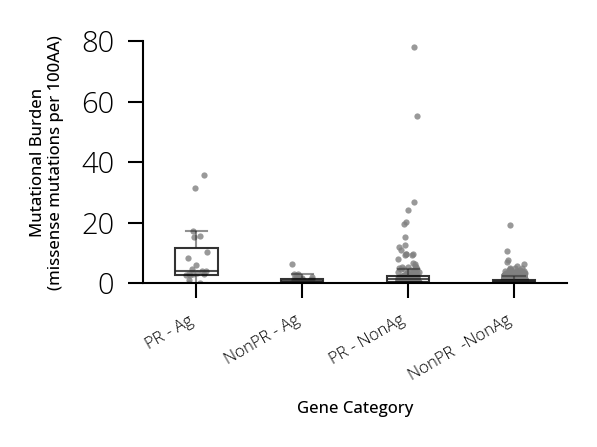

In [123]:
GWMutR_fig.savefig('./B_MutBurden_Results/MutationBurdenPerGene.Boxplots.AgVsNonAg.HHRvsNonHHR.V1.svg')
GWMutR_fig.savefig('./B_MutBurden_Results/MutationBurdenPerGene.Boxplots.AgVsNonAg.HHRvsNonHHR.V1.png')

GWMutR_fig

## Statistical Comparison of mutational burden (Genome-wide, 4 categories)


#### Look at distribution stats for each group (`Ag-HHR`, `NonAg-HHR`, `Ag-NonHHR`, `NonAg-NonHHR`)

In [100]:
MutationBurdenPerGene_GroupStats_DF = Genes_GCandMutFreqStats_DF.groupby("AntigenLVL2_And_HHR_Comb")["RelFreq_NS_Muts"].describe().reset_index()

In [101]:
MutationBurdenPerGene_GroupStats_DF

,AntigenLVL2_And_HHR_Comb,count,mean,std,min,25%,50%,75%,max
0,Antigen-HHR,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802
1,Antigen-Unq,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028
2,NonReactive-HHR,204.0,3.005899,7.481313,0.0,0.598638,1.332993,2.317748,78.102190
3,NonReactive-Unq,3584.0,0.889619,0.813826,0.0,0.385914,0.763359,1.231527,19.251337


In [102]:
MutationBurdenPerGene_GroupStats_TSV = "./B_MutBurden_Results/MutationBurdenPerGene.GroupSummStats.tsv"

MutationBurdenPerGene_GroupStats_DF.to_csv(MutationBurdenPerGene_GroupStats_TSV,
                                  sep = "\t", index=False)


#### Define mutation rate values for each group (Pandas Series)

In [103]:
UNQ_Nonantigen_MutRelFreq = Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'NonReactive-Unq'")["RelFreq_NS_Muts"]
UNQ_Antigen_MutRelFreq = Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-Unq'")["RelFreq_NS_Muts"]
HHR_Nonantigen_MutRelFreq = Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'NonReactive-HHR'")["RelFreq_NS_Muts"]
HHR_Antigen_MutRelFreq = Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["RelFreq_NS_Muts"]   

### Perform Statistical tests comparing all groups (Wilcoxon Rank Sum Test)

#### `UNQ_Nonantigen` vs `UNQ_Antigen` (p = `0.1922`)

In [104]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(UNQ_Nonantigen_MutRelFreq, UNQ_Antigen_MutRelFreq)

print("")
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}")


Wilcoxon rank-sum test statistic: -1.302851652989913
P-value: 0.19262541236327713


#### `UNQ_Nonantigen` vs `HHR_Nonantigen` (p = `1.54e-15`, **SIGNIFICANT!**)

In [105]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(UNQ_Nonantigen_MutRelFreq, HHR_Nonantigen_MutRelFreq)

print("")
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}")


Wilcoxon rank-sum test statistic: -7.967808254636011
P-value: 1.6151320474342523e-15


#### `UNQ_Nonantigen` vs `HHR_Antigen` (p = `2.84e-09`, **SIGNIFICANT!**)

In [106]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(UNQ_Nonantigen_MutRelFreq, HHR_Antigen_MutRelFreq)

print("`UNQ_Nonantigen` vs `HHR_Antigen`")
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}")

`UNQ_Nonantigen` vs `HHR_Antigen`
Wilcoxon rank-sum test statistic: -5.94079067614213
P-value: 2.8365061780427105e-09


#### `UNQ_Antigen` vs `HHR_Nonantigen` (p = `0.0568`)

In [107]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(UNQ_Antigen_MutRelFreq, HHR_Nonantigen_MutRelFreq)

print("`UNQ_Antigen` vs `HHR_Nonantigen`")
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}")

`UNQ_Antigen` vs `HHR_Nonantigen`
Wilcoxon rank-sum test statistic: -1.9061242721839262
P-value: 0.05663408427310985


#### `UNQ_Antigen` vs `HHR_Antigen` (p = `1.26e-05`, **SIGNIFICANT!**)

In [108]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(UNQ_Antigen_MutRelFreq, HHR_Antigen_MutRelFreq)

print("")
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}")


Wilcoxon rank-sum test statistic: -4.367156268334564
P-value: 1.2587467092606682e-05


#### `HHR_Nonantigen` vs `HHR_Antigen` (p = `3.67e-05`, **SIGNIFICANT!**)

In [109]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(HHR_Nonantigen_MutRelFreq, HHR_Antigen_MutRelFreq)

print("")
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}")


Wilcoxon rank-sum test statistic: -4.125294206184779
P-value: 3.7026113442146194e-05


# Part 3: Focused mutational burden analysis of `HHR vs Non-HHR antigens`

In [110]:
Antigen_GCandMutFreqStats_DF.shape

(53, 36)

In [111]:
Antigen_GCandMutFreqStats_DF.head(2)

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope
9,NC_000962.3,13132,13558,-,CDS,Rv0010c,Rv0010c,cell wall and cell processes,cell wall and cell processes,2,4,6,0.333333,13345.0,426,True,True,0,False,Antigen-Unq,0,0,9.0,2.0,0.0,0.0,0.0,9.0,6.338028,1.408451,False,False,False,False,False,True
123,NC_000962.3,151147,152215,+,CDS,Rv0125,pepA,intermediary metabolism and respiration,intermediary metabolism and respiration,3,69,72,0.041667,151681.0,1068,True,True,0,False,Antigen-Unq,0,0,5.0,0.0,0.0,0.0,0.0,5.0,1.404494,0.000000,False,False,False,False,False,True


## A) Compare OVERALL mutation burden between HHR and non-HHR antigens

The median mutational burden of HHR antigens is 4 missense mutations (IQR: 3-12) per 100 AA. <br>
The median mutational burden of Non-HHR antigens is 1 missense mutations (IQR: 0-2) per 100 AA. <br>
The mutational burden of HHR antigens is significantly higher than non-HHR antigens. <br>


In [112]:
Antigen_GCandMutFreqStats_DF.groupby("HasHmRegion")["RelFreq_NS_Muts"].describe()

,count,mean,std,min,25%,50%,75%,max
HasHmRegion,,,,,,,,
False,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028
True,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802


In [113]:
Antigen_NonHHR_RelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False")["RelFreq_NS_Muts"]
Antigen_HHR_RelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True")["RelFreq_NS_Muts"]


In [114]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(Antigen_NonHHR_RelFreq, Antigen_HHR_RelFreq)
# Output the result
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}") 

Wilcoxon rank-sum test statistic: -4.367156268334564
P-value: 1.2587467092606682e-05


In [115]:
### The median mutational burden on HHR antigens is 4 missense mutations (IQR: 3-12) per 100 AA .
### This is significantly higher than the mutational burden on non-HHR antigens, with a median of 1 missense mutations (IQR: 0-2) per 100 AA


In [116]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut != Has_mGCE_WiNSMut")

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope
2955,NC_000962.3,3376938,3378243,-,CDS,Rv3018c,PPE46,PE/PPE,PE/PPE,3,3,6,0.5,3377590.5,1305,True,True,1,True,Antigen-HHR,2,0,18.0,0.0,0.0,11.0,0.0,18.0,4.137931,0.0,False,False,False,True,True,True


In [117]:
Antigen_GCandMutFreqStats_DF.query("Total_NS_Muts_BymGCE != Total_NS_Muts_BypGCE").shape

(4, 36)

In [242]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut == True").shape

(10, 36)

In [243]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut == True").shape

(9, 36)

In [244]:
Antigen_GCandMutFreqStats_DF.groupby("AntigenLVL2_And_HHR_Comb")["RelFreq_NS_Muts"].describe()

,count,mean,std,min,25%,50%,75%,max
AntigenLVL2_And_HHR_Comb,,,,,,,,
Antigen-HHR,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802
Antigen-Unq,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028


In [245]:
Antigen_GCandMutFreqStats_DF.head(3)

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope
9,NC_000962.3,13132,13558,-,CDS,Rv0010c,Rv0010c,cell wall and cell processes,cell wall and cell processes,2,4,6,0.333333,13345.0,426,True,True,0,False,Antigen-Unq,0,0,9.0,2.0,0.0,0.0,0.0,9.0,6.338028,1.408451,False,False,False,False,False,True
123,NC_000962.3,151147,152215,+,CDS,Rv0125,pepA,intermediary metabolism and respiration,intermediary metabolism and respiration,3,69,72,0.041667,151681.0,1068,True,True,0,False,Antigen-Unq,0,0,5.0,0.0,0.0,0.0,0.0,5.0,1.404494,0.000000,False,False,False,False,False,True
174,NC_000962.3,207451,208420,+,CDS,Rv0176,Rv0176,cell wall and cell processes,cell wall and cell processes,2,3,5,0.400000,207935.5,969,True,True,0,False,Antigen-Unq,0,0,6.0,0.0,0.0,0.0,0.0,6.0,1.857585,0.000000,False,False,False,False,False,True


## B) Plot normalized mutation rate of HHR vs non-HHR antigens

#### Code to create plot

In [246]:
!mkdir ./B_MutBurden_Results/

mkdir: cannot create directory ‘./B_MutBurden_Results/’: File exists


Seed: 134


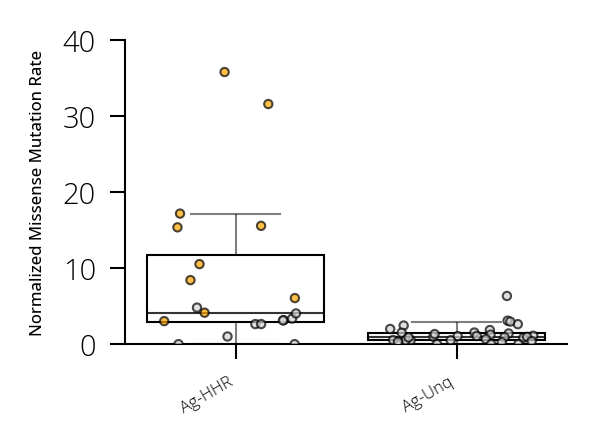

In [251]:
# Create figure and axis
AMutR_fig, AMutR_ax = plt.subplots(figsize=(2, 1.5))

seed_i = 134
print("Seed:", seed_i)

np.random.seed(seed_i)
in_GeneInfo_DF = Antigen_GCandMutFreqStats_DF

X_Order = ['Antigen-HHR', 'Antigen-Unq']

Has_GC_EpiMut_Pallete = { True : "Orange",
                          False : "lightgrey", }


sns.stripplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
               order = X_Order, hue = "Has_pGCE_WiNSMut", palette = Has_GC_EpiMut_Pallete,
               jitter = 0.35,
               data=in_GeneInfo_DF, dodge=False,
               alpha = 0.7, size = 2,
               edgecolor="black", linewidth=0.5, ax = AMutR_ax,
               legend=False, )


sns.boxplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
            order = X_Order,  
            data=in_GeneInfo_DF,
            legend=False, linewidth = 0.5, ax = AMutR_ax,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

# Y axis and labels
AMutR_ax.set_ylim(0, 40)
AMutR_ax.set_ylabel("Normalized Missense Mutation Rate", fontsize=4)
AMutR_ax.set_xlabel("")

# Replace long x-axis labels with shorter ones
short_labels = ['Ag-HHR', 'Ag-Unq']
AMutR_ax.set_xticks(range(len(X_Order)))
AMutR_ax.set_xticklabels(short_labels, fontsize=4, rotation=30, ha='right')

sns.despine(ax=AMutR_ax)

plt.tight_layout()

plt.show()


#plt.savefig('5B.RelMutFreq.PerAntigen.HHRvsNonHHR.ColorBymGCEGenes.V2.svg')

#### Show plot 

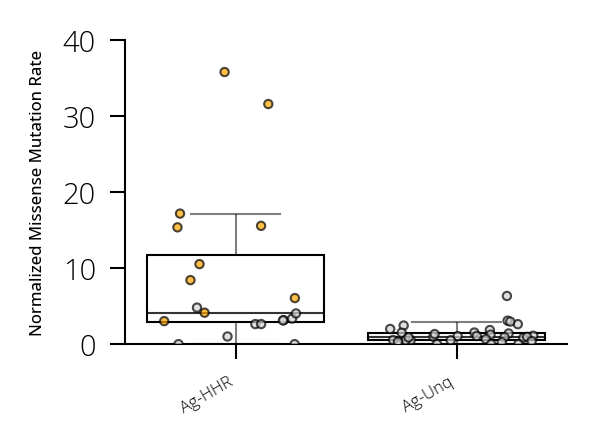

In [252]:
# AMutR_fig.savefig('./B_MutBurden_Results/MutationBurdenPerAntigen.Boxplots.HHRvsNonHHR.V1.svg')
# AMutR_fig.savefig('./B_MutBurden_Results/MutationBurdenPerAntigen.Boxplots.HHRvsNonHHR.V1.png')

AMutR_fig

Seed: 134


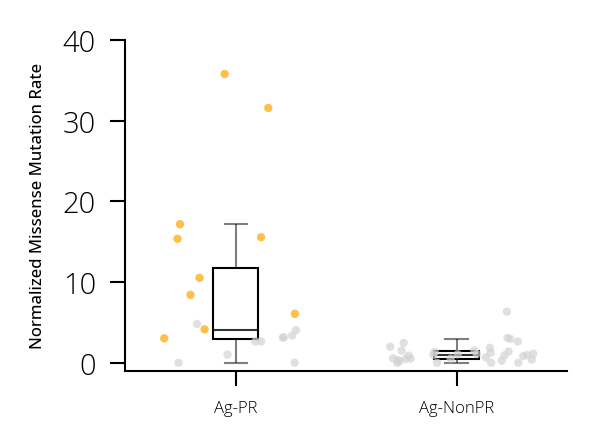

In [269]:
# Create figure and axis
AMutR_fig, AMutR_ax = plt.subplots(figsize=(2, 1.5))

seed_i = 134
print("Seed:", seed_i)

np.random.seed(seed_i)
in_GeneInfo_DF = Antigen_GCandMutFreqStats_DF

X_Order = ['Antigen-HHR', 'Antigen-Unq']

Has_GC_EpiMut_Pallete = { True : "Orange",
                          False : "lightgrey", }


sns.stripplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
               order = X_Order, hue = "Has_pGCE_WiNSMut", palette = Has_GC_EpiMut_Pallete,
               jitter = 0.35,
               data=in_GeneInfo_DF, dodge=False,
               alpha = 0.7, size = 2,
               edgecolor="black", linewidth=0, ax = AMutR_ax,
               legend=False, )


sns.boxplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
            order = X_Order,  
            data=in_GeneInfo_DF,
            legend=False, linewidth = 0.5, ax = AMutR_ax,
            showcaps=True, fliersize=0, width = 0.2,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

# Y axis and labels
AMutR_ax.set_ylim(-1, 40)
AMutR_ax.set_ylabel("Normalized Missense Mutation Rate", fontsize=4)
AMutR_ax.set_xlabel("")

# Replace long x-axis labels with shorter ones
short_labels = ['Ag-PR', 'Ag-NonPR']
AMutR_ax.set_xticks(range(len(X_Order)))
AMutR_ax.set_xticklabels(short_labels, fontsize=4, rotation=0, ha='center')

sns.despine(ax=AMutR_ax)

plt.tight_layout()

plt.show()


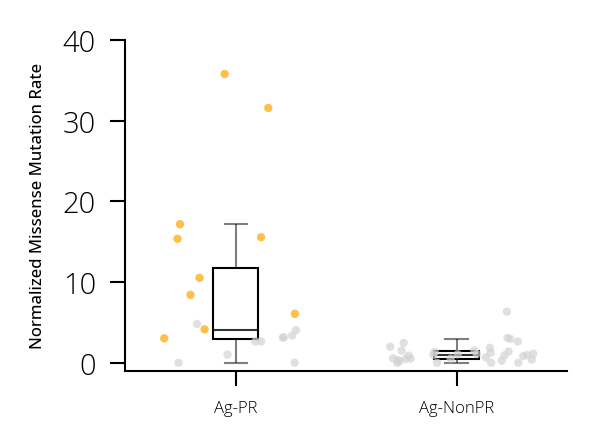

In [270]:
AMutR_fig.savefig('./B_MutBurden_Results/MutationBurdenPerAntigen.Boxplots.PRvsNonPR.ColorAnyWiGCE.V1.svg')
AMutR_fig.savefig('./B_MutBurden_Results/MutationBurdenPerAntigen.Boxplots.PRvsNonPR.ColorAnyWiGCE.V1.png')

AMutR_fig

### What are the top 10 antigens with the highest OVERALL mutational burden?

In [121]:
i_TarCols = [ "Symbol", "HasHmRegion", "RelFreq_NS_Muts", "pGCE_Ovrlap", "mGCE_Ovrlap", "N_Pos", "Total", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "Total_NS_Muts_BymGCE",   ]
# "Length", "H37rv_GeneID",
i_TarCols = [ "Symbol", "HasHmRegion", "RelFreq_NS_Muts", "pGCE_Ovrlap", "mGCE_Ovrlap", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "Total_NS_Muts_BymGCE",  "Total_NS_Muts_BypGCE",  ]

i_TarCols_V2 = [ "Symbol", "Length", "HasHmRegion", "RelFreq_NS_Muts", "RelFreq_NS_Mut_InEpitope", "Total_NS_Muts", "Total_NS_Muts_InEpitope", ]

Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols_V2].reset_index(drop=True)

,Symbol,Length,HasHmRegion,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope
0,PPE60,1182,True,35.786802,6.091371,141.0,24.0
1,esxL,285,True,31.578947,28.421053,30.0,27.0
2,esxP,297,True,17.171717,2.020202,17.0,2.0
3,PPE18,1176,True,15.561224,11.224490,61.0,44.0
4,PPE19,1191,True,15.365239,2.267003,61.0,9.0
5,esxO,285,True,10.526316,3.157895,10.0,3.0
6,esxN,285,True,8.421053,1.052632,8.0,1.0
7,Rv0010c,426,False,6.338028,1.408451,9.0,2.0
8,esxK,297,True,6.060606,3.030303,6.0,3.0
9,Rv3115,1248,True,4.807692,0.240385,20.0,1.0


In [122]:
Antigen_GCandMutFreqStats_DF.groupby("AntigenLVL2_And_HHR_Comb")["RelFreq_NS_Muts"].describe()

,count,mean,std,min,25%,50%,75%,max
AntigenLVL2_And_HHR_Comb,,,,,,,,
Antigen-HHR,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802
Antigen-Unq,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028


In [123]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols].reset_index(drop=True)

,Symbol,HasHmRegion,RelFreq_NS_Muts,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE
0,PPE60,True,35.786802,8,8,141.0,24.0,120.0,120.0
1,esxL,True,31.578947,10,7,30.0,27.0,13.0,20.0
2,esxP,True,17.171717,9,9,17.0,2.0,12.0,12.0
3,PPE18,True,15.561224,8,7,61.0,44.0,45.0,46.0
4,PPE19,True,15.365239,5,5,61.0,9.0,36.0,36.0
5,esxO,True,10.526316,5,5,10.0,3.0,6.0,6.0
6,esxN,True,8.421053,3,3,8.0,1.0,7.0,7.0
7,Rv0010c,False,6.338028,0,0,9.0,2.0,0.0,0.0
8,esxK,True,6.060606,5,3,6.0,3.0,1.0,3.0
9,Rv3115,True,4.807692,0,0,20.0,1.0,0.0,0.0


In [133]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(20)[i_TarCols].reset_index(drop=True)

,Symbol,HasHmRegion,RelFreq_NS_Muts,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE
0,PPE60,True,35.786802,8,8,141.0,24.0,120.0,120.0
1,esxL,True,31.578947,10,7,30.0,27.0,13.0,20.0
2,esxP,True,17.171717,9,9,17.0,2.0,12.0,12.0
3,PPE18,True,15.561224,8,7,61.0,44.0,45.0,46.0
4,PPE19,True,15.365239,5,5,61.0,9.0,36.0,36.0
5,esxO,True,10.526316,5,5,10.0,3.0,6.0,6.0
6,esxN,True,8.421053,3,3,8.0,1.0,7.0,7.0
7,Rv0010c,False,6.338028,0,0,9.0,2.0,0.0,0.0
8,esxK,True,6.060606,5,3,6.0,3.0,1.0,3.0
9,Rv3115,True,4.807692,0,0,20.0,1.0,0.0,0.0


In [134]:
Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols].reset_index(drop=True)

,Symbol,HasHmRegion,RelFreq_NS_Muts,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE
0,PPE60,True,35.786802,8,8,141.0,24.0,120.0,120.0
1,esxL,True,31.578947,10,7,30.0,27.0,13.0,20.0
2,esxP,True,17.171717,9,9,17.0,2.0,12.0,12.0
3,PPE18,True,15.561224,8,7,61.0,44.0,45.0,46.0
4,PPE19,True,15.365239,5,5,61.0,9.0,36.0,36.0


In [135]:
Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V2].reset_index(drop=True)

,Symbol,Length,HasHmRegion,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope
0,PPE60,1182,True,35.786802,6.091371,141.0,24.0
1,esxL,285,True,31.578947,28.421053,30.0,27.0
2,esxP,297,True,17.171717,2.020202,17.0,2.0
3,PPE18,1176,True,15.561224,11.224490,61.0,44.0
4,PPE19,1191,True,15.365239,2.267003,61.0,9.0


In [136]:
Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V2].reset_index(drop=True)

,Symbol,Length,HasHmRegion,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope
0,Rv0010c,426,False,6.338028,1.408451,9.0,2.0
1,esxH,291,False,3.092784,3.092784,3.0,3.0
2,esxB,303,False,2.970297,2.970297,3.0,3.0
3,Rv2660c,228,False,2.631579,1.315789,2.0,1.0
4,rimJ,612,False,2.450980,0.490196,5.0,1.0


### Create table of top 5 HHR and Non-HHR antigens (Ranked by mut-burden in each group)

In [137]:
i_TarCols_V3 = ["HasHmRegion", "Symbol", "Length", "RelFreq_NS_Muts", "RelFreq_NS_Mut_InEpitope", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "pGCE_Ovrlap", "mGCE_Ovrlap",]

Top5_HHR_Antigen_GCandMutFreqStats_DF = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V3].reset_index(drop=True)

Top5_UNQ_Antigen_GCandMutFreqStats_DF = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V3].reset_index(drop=True)


Top5HHR_Vs_Top5Unq_Antigens_Stats_DF = pd.concat([Top5_HHR_Antigen_GCandMutFreqStats_DF, Top5_UNQ_Antigen_GCandMutFreqStats_DF],
                                                 axis =0 )
Top5HHR_Vs_Top5Unq_Antigens_Stats_DF.shape

(10, 9)

In [138]:
Top5HHR_Vs_Top5Unq_Antigens_Stats_DF

,HasHmRegion,Symbol,Length,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope,pGCE_Ovrlap,mGCE_Ovrlap
0,True,PPE60,1182,35.786802,6.091371,141.0,24.0,8,8
1,True,esxL,285,31.578947,28.421053,30.0,27.0,10,7
2,True,esxP,297,17.171717,2.020202,17.0,2.0,9,9
3,True,PPE18,1176,15.561224,11.224490,61.0,44.0,8,7
4,True,PPE19,1191,15.365239,2.267003,61.0,9.0,5,5
0,False,Rv0010c,426,6.338028,1.408451,9.0,2.0,0,0
1,False,esxH,291,3.092784,3.092784,3.0,3.0,0,0
2,False,esxB,303,2.970297,2.970297,3.0,3.0,0,0
3,False,Rv2660c,228,2.631579,1.315789,2.0,1.0,0,0
4,False,rimJ,612,2.450980,0.490196,5.0,1.0,0,0


In [139]:
# Save as TSV
Top5HHR_Vs_Top5Unq_Antigens_Stats_DF.to_csv("./B_MutBurden_Results/Top5HHR.Vs.Top5UNQ.Antigens.MutBurdenStats.tsv", sep = "\t", index=False)

### Create table of top 10 antigens (Ranked by mut-burden)

In [140]:
Top10MutBurden_Antigen_Stats_DF = Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols_V3].reset_index(drop=True)
Top10MutBurden_Antigen_Stats_DF.shape

(10, 9)

In [141]:
# Save as TSV
Top10MutBurden_Antigen_Stats_DF.to_csv("./B_MutBurden_Results/Top10.All.Antigens.MutBurdenStats.tsv", sep = "\t", index=False)

In [142]:
Top10MutBurden_Antigen_Stats_DF

,HasHmRegion,Symbol,Length,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope,pGCE_Ovrlap,mGCE_Ovrlap
0,True,PPE60,1182,35.786802,6.091371,141.0,24.0,8,8
1,True,esxL,285,31.578947,28.421053,30.0,27.0,10,7
2,True,esxP,297,17.171717,2.020202,17.0,2.0,9,9
3,True,PPE18,1176,15.561224,11.224490,61.0,44.0,8,7
4,True,PPE19,1191,15.365239,2.267003,61.0,9.0,5,5
5,True,esxO,285,10.526316,3.157895,10.0,3.0,5,5
6,True,esxN,285,8.421053,1.052632,8.0,1.0,3,3
7,False,Rv0010c,426,6.338028,1.408451,9.0,2.0,0,0
8,True,esxK,297,6.060606,3.030303,6.0,3.0,5,3
9,True,Rv3115,1248,4.807692,0.240385,20.0,1.0,0,0


# Part 4: Analysis of mutational burden in EPITOPES of antigens ( `HHR` vs `Non-HHR`)

## Investigate statistics + numbers for comparison of EPITOPE mutational burden

In [143]:
Antigen_NonHHR_EpiMutRelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False")["RelFreq_NS_Mut_InEpitope"]
Antigen_HHR_EpiMutRelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True")["RelFreq_NS_Mut_InEpitope"]

In [144]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(Antigen_NonHHR_EpiMutRelFreq, Antigen_HHR_EpiMutRelFreq)
# Output the result
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}") 

Wilcoxon rank-sum test statistic: -3.3946382758062783
P-value: 0.0006871932824568401


In [145]:
EpiMutBurden_GroupStats_DF = Antigen_GCandMutFreqStats_DF.groupby("AntigenLVL2_And_HHR_Comb")["RelFreq_NS_Mut_InEpitope"].describe().reset_index()

In [146]:
EpiMutBurden_GroupStats_DF

,AntigenLVL2_And_HHR_Comb,count,mean,std,min,25%,50%,75%,max
0,Antigen-HHR,20.0,3.490013,6.446048,0.0,0.420673,1.487854,3.157895,28.421053
1,Antigen-Unq,33.0,0.400851,0.771042,0.0,0.000000,0.075131,0.325733,3.092784


In [147]:
EpiMutBurden_GroupStats_TSV = "B_MutBurden_Results/EpitopeMutationBurdenPerAntigen.GroupSummStats.tsv"

EpiMutBurden_GroupStats_DF.to_csv(EpiMutBurden_GroupStats_TSV,
                                  sep = "\t", index=False)



In [148]:
#Antigen_NSMutInfo_DF.groupby("HasHmRegion")["RelFreq_NS_Mut_InEpitope"].describe()

## D) Plot mutational burden in verified epitopes of HHR vs non-HHR antigens

#### Code to create plot

Seed: 131


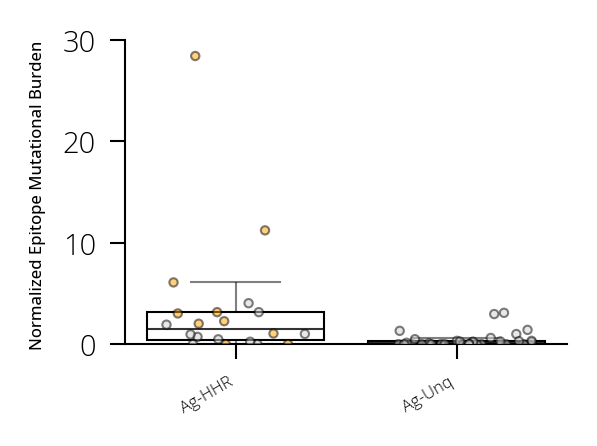

In [149]:
# Create figure and axis
EpiMutR_fig, EpiMutR_ax = plt.subplots(figsize=(2, 1.5))

seed_i = 131
print("Seed:", seed_i)

np.random.seed(seed_i)
in_GeneInfo_DF = Antigen_GCandMutFreqStats_DF

X_Order = ['Antigen-HHR', 'Antigen-Unq']

Has_GC_EpiMut_Pallete = { True : "Orange",
                          False : "lightgrey", }


sns.stripplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Mut_InEpitope",
               order = X_Order,  hue = "Has_pGCE_WiNSMut",
               jitter = 0.35, palette = Has_GC_EpiMut_Pallete,
               data=in_GeneInfo_DF, dodge=False,
               alpha = 0.5, size = 2,
               edgecolor="black", linewidth=0.5, ax = EpiMutR_ax,
               legend=False,
               )


sns.boxplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Mut_InEpitope",
            order = X_Order,  
            data=in_GeneInfo_DF,
            legend=False, linewidth = 0.5, ax = EpiMutR_ax,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

# Y axis and labels
EpiMutR_ax.set_ylim(0, 30)
EpiMutR_ax.set_ylabel("Normalized Epitope Mutational Burden ", fontsize=4)
EpiMutR_ax.set_xlabel("")

# Replace long x-axis labels with shorter ones
short_labels = ['Ag-HHR', 'Ag-Unq']
EpiMutR_ax.set_xticks(range(len(X_Order)))
EpiMutR_ax.set_xticklabels(short_labels, fontsize=4, rotation=30, ha='right')

sns.despine(ax=EpiMutR_ax)

sns.despine()
plt.show()


#### Show plot 

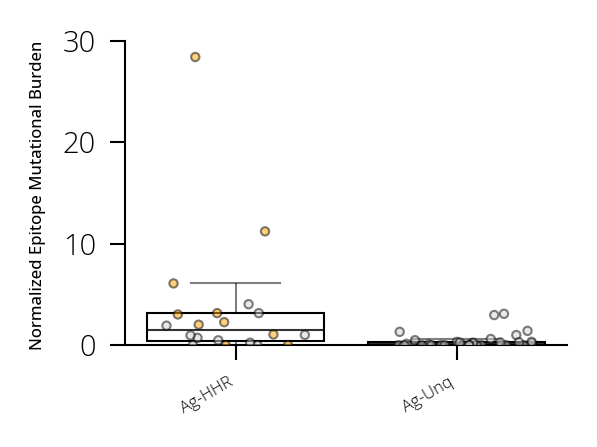

In [150]:
EpiMutR_fig.savefig('./B_MutBurden_Results/EpitopeMutationBurdenPerAntigen.Boxplots.HHRvsNonHHR.V1.svg')
EpiMutR_fig.savefig('./B_MutBurden_Results/EpitopeMutationBurdenPerAntigen.Boxplots.HHRvsNonHHR.V1.png')

EpiMutR_fig

### What are the top 10 antigens with the highest EPITOPE mutational burden?

In [151]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Mut_InEpitope", ascending=False).head(10)[i_TarCols_V2]

,Symbol,Length,HasHmRegion,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope
1174,esxL,285,True,31.578947,28.421053,30.0,27.0
1172,PPE18,1176,True,15.561224,11.224490,61.0,44.0
3397,PPE60,1182,True,35.786802,6.091371,141.0,24.0
3538,esxW,297,True,4.040404,4.040404,4.0,4.0
1023,esxI,285,True,3.157895,3.157895,3.0,3.0
2294,esxO,285,True,10.526316,3.157895,10.0,3.0
286,esxH,291,False,3.092784,3.092784,3.0,3.0
1173,esxK,297,True,6.060606,3.030303,6.0,3.0
3790,esxB,303,False,2.970297,2.970297,3.0,3.0
1337,PPE19,1191,True,15.365239,2.267003,61.0,9.0


#### The top 3 antigens with the highest normalized mutational density in epitopes are: `PPE18`, `esxL`, `PPE60`

In [152]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Mut_InEpitope", ascending=False).head(5)[i_TarCols_V2]

,Symbol,Length,HasHmRegion,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope
1174,esxL,285,True,31.578947,28.421053,30.0,27.0
1172,PPE18,1176,True,15.561224,11.224490,61.0,44.0
3397,PPE60,1182,True,35.786802,6.091371,141.0,24.0
3538,esxW,297,True,4.040404,4.040404,4.0,4.0
1023,esxI,285,True,3.157895,3.157895,3.0,3.0


# Part X: Output all tables of key data for this analysis

# Any Extra Exploration